# 4.2 多层感知机的从零开始实现

本节在 Fashion-MNIST 上手写单隐藏层 MLP。模型参数、ReLU、指标和训练循环都由我们实现；只借助 PyTorch 的张量、自动微分、交叉熵和优化器，不使用 `d2l`。

原教材：[4.2 多层感知机的从零开始实现](https://zh.d2l.ai/chapter_multilayer-perceptrons/mlp-scratch.html)

## 学习目标

1. 手动创建并管理两层网络的权重和偏置；
2. 从定义实现 ReLU 和 MLP 前向传播；
3. 自行完成数据加载、训练、评估、绘图和预测；
4. 理解隐藏单元数、层数、学习率等超参数的影响。

In [1]:
import sys  # 判断操作系统，Windows 下使用单进程加载更稳妥
from pathlib import Path  # 管理数据目录

import matplotlib.pyplot as plt  # 绘图
import torch  # 张量与自动微分
import torchvision  # Fashion-MNIST 数据集
from torch import nn  # 仅使用损失函数和 Parameter，不用 Linear/ReLU
from torch.utils.data import DataLoader  # 小批量迭代器
from torchvision import transforms  # 图像转张量

torch.manual_seed(42)  # 固定随机种子，使参数初始化与抽样结果可复现
batch_size = 256  # 每个小批量包含 256 张图片
data_root = Path('../data')  # 指定 Fashion-MNIST 的下载与缓存目录
num_workers = 0 if sys.platform.startswith('win') else 2  # Windows 使用主进程加载以避免多进程问题

train_dataset = torchvision.datasets.FashionMNIST(  # 创建训练数据集对象
    root=data_root, train=True, transform=transforms.ToTensor(), download=True  # 下载训练集并把图片转为张量
)  # 完成训练数据集配置
test_dataset = torchvision.datasets.FashionMNIST(  # 创建测试数据集对象
    root=data_root, train=False, transform=transforms.ToTensor(), download=True  # 下载测试集并把图片转为张量
)  # 完成测试数据集配置
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers)  # 随机打乱训练样本并按批读取
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers)  # 按固定顺序分批读取测试样本
print(len(train_dataset), len(test_dataset))  # 输出训练集与测试集的样本数

60000 10000


## 4.2.1 初始化模型参数

每张 $28\times28$ 图像展平后有 784 个输入，Fashion-MNIST 有 10 类。采用 256 个隐藏单元：

$$\mathbf W_1:[784,256],\quad\mathbf b_1:[256],\quad\mathbf W_2:[256,10],\quad\mathbf b_2:[10].$$

权重使用标准差 0.01 的正态分布，偏置初始化为 0。`nn.Parameter` 会注册梯度，但这里参数仍由列表手动管理。

In [2]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256  # 设置输入数、类别数和隐藏单元数
W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * 0.01)  # 创建输入层到隐藏层的可训练权重 [784,256]
b1 = nn.Parameter(torch.zeros(num_hiddens))  # 创建隐藏层可训练偏置 [256]
W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * 0.01)  # 创建隐藏层到输出层的可训练权重 [256,10]
b2 = nn.Parameter(torch.zeros(num_outputs))  # 创建输出层可训练偏置 [10]
params = [W1, b1, W2, b2]  # 收集全部参数，稍后交给优化器更新
print('参数总数:', sum(parameter.numel() for parameter in params))  # 统计模型中所有标量参数的数量

参数总数: 203530


## 4.2.2 激活函数

按定义实现 $\operatorname{ReLU}(x)=\max(x,0)$。`torch.clamp_min(X, 0)` 是逐元素操作，不会改变张量形状。

In [3]:
def relu(X):  # 从零定义逐元素 ReLU 激活函数
    return torch.clamp_min(X, 0)  # 小于 0 的元素置 0

relu_test = torch.tensor([-2.0, 0.0, 3.0])  # 构造包含负数、零和正数的测试输入
print(relu(relu_test))  # 检查 ReLU 是否输出 [0,0,3]

tensor([0., 0., 3.])


## 4.2.3 模型

输入先展平，再依次执行隐藏层仿射变换、ReLU 和输出层仿射变换。模型返回 logits，不额外计算 softmax，因为交叉熵会更稳定地合并 `log_softmax` 与负对数似然。实现前向传播。

In [4]:
def net(X):  # 定义单隐藏层多层感知机的前向传播
    X = X.reshape(-1, num_inputs)  # [B,1,28,28] -> [B,784]
    H = relu(X @ W1 + b1)  # [B,784]@[784,256] -> [B,256]
    return H @ W2 + b2  # [B,256]@[256,10] -> [B,10]

sample_X, _ = next(iter(train_iter))  # 取出一个训练批次并忽略其标签
print('logits 形状:', net(sample_X[:4]).shape)  # 检查 4 个样本是否得到 [4,10] 输出

logits 形状: torch.Size([4, 10])


## 4.2.4 损失函数

`CrossEntropyLoss` 直接接收 `[B,10]` logits 和 `[B]` 整数标签。使用默认 `mean` 归约，使每批损失为样本平均值。

In [5]:
loss_fn = nn.CrossEntropyLoss()  # 创建适用于多分类 logits 的交叉熵损失函数
example_logits = net(sample_X[:4])  # 对 4 个样本执行前向传播得到 logits
print('示例损失:', loss_fn(example_logits, torch.tensor([0, 1, 2, 3])).item())  # 用虚拟标签计算并输出标量损失

示例损失: 2.3052711486816406


## 4.2.5 训练

每个小批量依次执行：清梯度、前向传播、计算平均损失、反向传播、更新参数。以下函数完整替代教材中的 `d2l.train_ch3`。

In [6]:
def evaluate_accuracy(model, data_iter):  # 定义模型在指定数据集上的准确率评估函数
    correct, total = 0, 0  # 初始化预测正确数与样本总数
    with torch.no_grad():  # 评估阶段关闭梯度记录以节省内存和计算量
        for X, y in data_iter:  # 逐批读取特征 X 和真实标签 y
            predictions = model(X).argmax(dim=1)  # 前向计算并选取每行最大 logit 对应的类别
            correct += int((predictions == y).sum())  # 累加当前批次预测正确的样本数
            total += y.numel()  # 累加当前批次的标签数量
    return correct / total  # 返回整个数据集上的分类准确率

def train_model(model, train_iter, test_iter, loss_fn, optimizer, num_epochs):  # 定义完整训练流程
    history = {'train_loss': [], 'train_acc': [], 'test_acc': []}  # 保存每轮指标以便后续绘图
    for epoch in range(num_epochs):  # 重复遍历训练集 num_epochs 轮
        loss_sum, correct, total = 0.0, 0, 0  # 重置本轮损失总和、正确数和样本数
        for X, y in train_iter:  # 逐个小批量训练模型
            optimizer.zero_grad()  # 清除上一批次残留在参数上的梯度
            logits = model(X)  # 前向传播得到每个类别的未归一化分数
            loss = loss_fn(logits, y)  # 比较 logits 与真实标签并计算平均损失
            loss.backward()  # 反向传播，计算损失关于各参数的梯度
            optimizer.step()  # 根据梯度和学习率更新 W1、b1、W2、b2
            loss_sum += loss.item() * y.numel()  # 将批平均损失还原为损失总和后累计
            correct += int((logits.argmax(dim=1) == y).sum())  # 累加本批预测正确数
            total += y.numel()  # 累加本批样本数
        train_loss = loss_sum / total  # 计算本轮每个样本的平均训练损失
        train_acc = correct / total  # 计算本轮训练准确率
        test_acc = evaluate_accuracy(model, test_iter)  # 在测试集上评估模型泛化能力
        history['train_loss'].append(train_loss)  # 记录本轮训练损失
        history['train_acc'].append(train_acc)  # 记录本轮训练准确率
        history['test_acc'].append(test_acc)  # 记录本轮测试准确率
        print(f'epoch {epoch + 1:2d}: loss {train_loss:.4f}, train acc {train_acc:.3f}, test acc {test_acc:.3f}')  # 输出本轮指标
    return history  # 返回全部训练历史

epoch  1: loss 1.0435, train acc 0.640, test acc 0.721
epoch  2: loss 0.6010, train acc 0.789, test acc 0.797
epoch  3: loss 0.5215, train acc 0.818, test acc 0.770
epoch  4: loss 0.4830, train acc 0.831, test acc 0.817
epoch  5: loss 0.4544, train acc 0.840, test acc 0.828
epoch  6: loss 0.4354, train acc 0.848, test acc 0.827
epoch  7: loss 0.4191, train acc 0.852, test acc 0.824
epoch  8: loss 0.4077, train acc 0.856, test acc 0.841
epoch  9: loss 0.3927, train acc 0.862, test acc 0.819
epoch 10: loss 0.3834, train acc 0.864, test acc 0.848


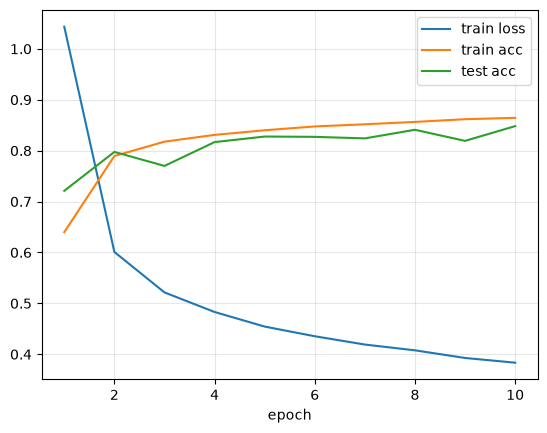

In [7]:
num_epochs, learning_rate = 10, 0.1  # 设置训练轮数和 SGD 学习率
optimizer = torch.optim.SGD(params, lr=learning_rate)  # 创建负责更新手动参数列表的随机梯度下降优化器
history = train_model(net, train_iter, test_iter, loss_fn, optimizer, num_epochs)  # 启动训练并接收指标历史

epochs = range(1, num_epochs + 1)  # 生成从 1 开始的轮次横坐标
plt.plot(epochs, history['train_loss'], label='train loss')  # 绘制训练损失曲线
plt.plot(epochs, history['train_acc'], label='train acc')  # 绘制训练准确率曲线
plt.plot(epochs, history['test_acc'], label='test acc')  # 绘制测试准确率曲线
plt.xlabel('epoch')  # 设置横轴名称为训练轮次
plt.grid(alpha=0.3)  # 添加半透明网格辅助读数
plt.legend()  # 显示三条曲线的图例
plt.show()  # 在 Notebook 中显示训练曲线

### 预测展示

下面自行实现类别名称映射和可视化，替代 `d2l.predict_ch3`。

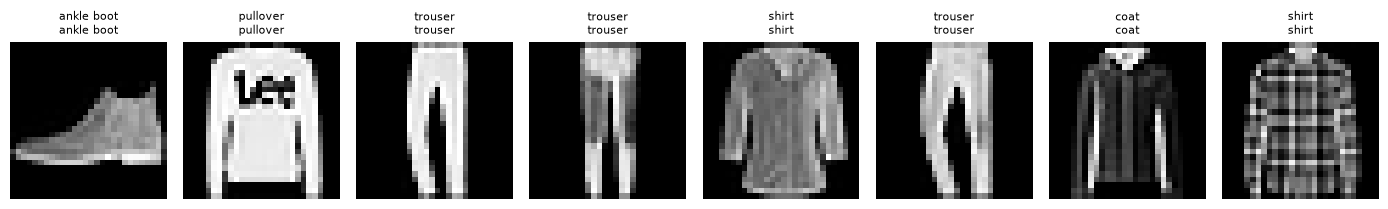

In [8]:
fashion_labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',  # 定义类别 0 到 4 的英文名称
                  'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']  # 定义类别 5 到 9 的英文名称
X, y = next(iter(test_iter))  # 读取一个测试批次的图片和真实标签
with torch.no_grad():  # 预测时关闭梯度记录
    predictions = net(X[:8]).argmax(dim=1)  # 预测前 8 张图片的类别
fig, axes = plt.subplots(1, 8, figsize=(14, 2))  # 创建一行八列的预测结果画布
for axis, image, truth, prediction in zip(axes, X[:8], y[:8], predictions):  # 同步遍历坐标轴、图片、真值和预测值
    axis.imshow(image.squeeze(), cmap='gray')  # 删除通道维并以灰度图显示图片
    axis.set_title(f'{fashion_labels[int(truth)]}\n{fashion_labels[int(prediction)]}', fontsize=8)  # 第一行显示真值，第二行显示预测
    axis.axis('off')  # 隐藏坐标轴刻度和边框
plt.tight_layout()  # 自动调整子图间距
plt.show()  # 显示预测结果

## 4.2.6 小结

- 单隐藏层 MLP 比 softmax 回归多出一组参数和非线性激活；
- 模型输出 logits，并交给稳定的交叉熵函数；
- 训练骨架与 softmax 回归相同；
- 手写实现有助于理解计算过程，但层数增加后，参数命名和管理会迅速变得繁琐。

## 4.2.7 练习

1. 保持其他参数不变，修改 `num_hiddens`，观察其影响并确定最佳值。
2. 添加更多隐藏层并观察影响。
3. 保持架构和轮数不变，改变学习率，哪个值最好？
4. 联合优化学习率、轮数、隐藏层数和各层隐藏单元数，能得到的最佳结果是什么？
5. 为什么同时涉及多个超参数时更具挑战性？
6. 如果要构建多超参数搜索方法，请设计一个聪明的策略。

## 4.2.8 练习题参考答案

### 练习 1

隐藏单元太少会欠拟合；增大宽度通常先提高精度，之后收益递减，并增加参数量、时间和过拟合风险。“最佳值”依赖数据划分、随机种子和训练预算，不能脱离实验给出固定数字。可在验证集上比较 $64,128,256,512$，选择验证精度最高者，不能根据测试集调参。

### 练习 2

例如两层隐藏层可写为 $H_1=\operatorname{ReLU}(XW_1+b_1)$、$H_2=\operatorname{ReLU}(H_1W_2+b_2)$、$O=H_2W_3+b_3$。更深网络表达能力更强，但也更难优化、更耗时，并可能过拟合。Fashion-MNIST 较简单，盲目加深未必优于一两个隐藏层。

### 练习 3

学习率过小会收敛慢，过大会震荡甚至发散。可固定随机种子，在验证集比较如 $0.001,0.01,0.03,0.1,0.3,1.0$ 的对数尺度候选。原配置的 `0.1` 是合理起点，但最佳值须由实际验证曲线决定。

### 练习 4

不存在无需实验即可保证的最佳组合。规范做法是从训练集划出验证集，在相同数据划分和预算下搜索；最终只用一次测试集报告结果。一个常见强基线是 1–2 个隐藏层、每层 128–512 单元，配合在对数尺度上搜索的学习率和足够轮数，并以后续章节的正则化方法控制过拟合。

### 练习 5

若每个超参数有 $k$ 个候选、共有 $m$ 个超参数，网格搜索需 $k^m$ 次实验，成本呈指数增长；超参数之间还存在交互，例如更深网络可能需要不同学习率和训练轮数。随机噪声及不同训练成本也使公平比较更困难。

### 练习 6

优先采用随机搜索：对学习率等尺度参数按对数均匀采样，对层数、宽度采样离散值；先给每组配置少量轮数，提前停止表现差的实验，再给有希望的配置增加资源。这就是逐次减半/Hyperband 的核心思想。最后对优胜配置使用多个随机种子复验。